# Feature Engineering

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline


SEED = 143

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

LOCAL_DIR = Path(".local/feature_engineering")
LOCAL_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

X_train = train_df.drop(columns=['id', 'target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['id'])


Дубликатов нет (см. [`00_EDA.ipynb`](./00_EDA.ipynb)). Значения `-1` не удаляю: сам факт пропуска может содержать сигнал.


In [3]:
def normalized_gini(y_true, y_pred_proba):  # в cross_val_score по умолчанию его нет, но он легко выражается из roc_auc
    return 2 * roc_auc_score(y_true, y_pred_proba) - 1


gini_scorer = make_scorer(
    normalized_gini,
    response_method="predict_proba",
)


### Feature engineering

Для сравнения наборов признаков использую небольшой `RandomForestClassifier`. Ему не нужны скейлинг и One-Hot Encoding, поэтому эксперименты остаются простыми.

`PCA` здесь не проверяю: для деревьев смешивание исходных признаков обычно только мешает интерпретируемым разбиениям.


In [4]:
feature_model = RandomForestClassifier(
    n_estimators=160,
    max_depth=10,
    min_samples_leaf=50,
    max_samples=0.4,
    random_state=SEED,
    n_jobs=-1
)

scores = cross_val_score(
    feature_model,
    X_train,
    y_train,
    cv=cv,
    scoring=gini_scorer,
    n_jobs=1
)


Отдельно проверю заполнение числовых пропусков медианой. Флаги пропусков сохраняют сам факт исходного `-1`.


In [5]:
numeric_columns = [
    column for column in X_train.columns
    if not column.endswith(('_cat', '_bin'))
]

preprocessor_with_imputation = ColumnTransformer(
    transformers=[
        (
            'num',
            SimpleImputer(missing_values=-1, strategy='median', add_indicator=True),
            numeric_columns
        ),
    ],
    remainder='passthrough',
    n_jobs=-1
)

feature_model_with_imputation = make_pipeline(
    preprocessor_with_imputation,
    feature_model
)

scores_with_imputation = cross_val_score(
    feature_model_with_imputation,
    X_train,
    y_train,
    cv=cv,
    scoring=gini_scorer,
    n_jobs=1
)


Проверю удаление почти константных признаков в двух вариантах.


In [6]:
drop_constants = [
    'ps_ind_05_cat',
    'ps_ind_10_bin',
    'ps_ind_11_bin',
    'ps_ind_12_bin',
    'ps_ind_13_bin',
    'ps_ind_14',
    'ps_car_04_cat',
    'ps_car_07_cat',
    'ps_car_10_cat',
]

drop_constants_lite = [
    'ps_ind_10_bin',
    'ps_ind_11_bin',
    'ps_ind_12_bin',
    'ps_ind_13_bin',
    'ps_ind_14',
    'ps_car_10_cat',
]

drop_uniform = [
    'ps_calc_01',
    'ps_calc_02',
    'ps_calc_03',
]

feature_sets = {
    'all_features': X_train,
    'no_constants': X_train.drop(columns=drop_constants),
    'no_constants_lite': X_train.drop(columns=drop_constants_lite),
    'no_uniform': X_train.drop(columns=drop_uniform),
    'no_constants_lite_no_uniform': X_train.drop(
        columns=drop_constants_lite + drop_uniform
    ),
}


In [7]:
feature_scores = {
    'all_features': scores,
}

for experiment, X_experiment in feature_sets.items():
    if experiment == 'all_features':
        continue

    feature_scores[experiment] = cross_val_score(
        feature_model,
        X_experiment,
        y_train,
        cv=cv,
        scoring=gini_scorer,
        n_jobs=1
    )


In [8]:
feature_results = pd.DataFrame([
    {
        'experiment': experiment,
        'n_features': X_experiment.shape[1],
        'mean_gini': feature_scores[experiment].mean(),
        'std_gini': feature_scores[experiment].std(),
    }
    for experiment, X_experiment in feature_sets.items()
] + [
    {
        'experiment': 'median_with_missing_flags',
        'n_features': X_train.shape[1],
        'mean_gini': scores_with_imputation.mean(),
        'std_gini': scores_with_imputation.std(),
    }
]).sort_values('mean_gini', ascending=False).reset_index(drop=True)

feature_results


,experiment,n_features,mean_gini,std_gini
0,no_constants_lite,51,0.264617,0.008513
1,no_constants_lite_no_uniform,48,0.263657,0.007761
2,all_features,57,0.262900,0.007352
3,no_uniform,54,0.262653,0.009297
4,median_with_missing_flags,57,0.261852,0.007701
5,no_constants,48,0.246232,0.009207


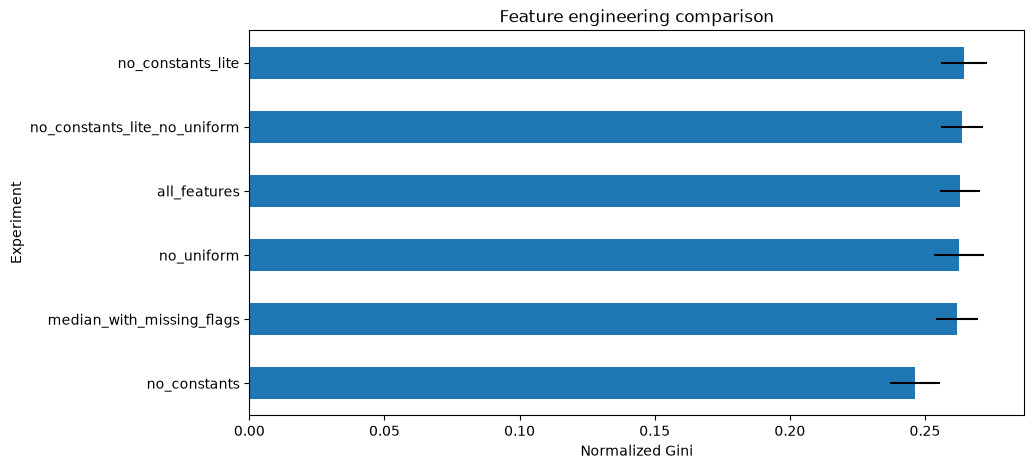

In [9]:
ax = (
    feature_results
    .sort_values('mean_gini')
    .plot(
        x='experiment',
        y='mean_gini',
        xerr='std_gini',
        kind='barh',
        figsize=(10, 5),
        legend=False,
        xlabel='Normalized Gini',
        ylabel='Experiment',
        title='Feature engineering comparison'
    )
)

plt.show()


Для дальнейших моделей выбираю лучший вариант, который оставляет обычный набор столбцов. Эксперимент с медианой остается отдельным пайплайном и автоматически здесь не выбирается.


In [10]:
raw_feature_results = feature_results[
    feature_results['experiment'] != 'median_with_missing_flags'
]

best_feature_experiment = raw_feature_results.iloc[0]['experiment']
selected_columns = feature_sets[best_feature_experiment].columns.tolist()

with open(LOCAL_DIR / "selected_features.json", "w") as file:
    json.dump(selected_columns, file, indent=4)

pd.DataFrame({
    'selected_experiment': [best_feature_experiment],
    'n_features': [len(selected_columns)],
})


,selected_experiment,n_features
0,no_constants_lite,51


In [11]:
X_train = X_train[selected_columns]
X_test = X_test[selected_columns]

pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [X_train.shape[0], X_test.shape[0]],
    'features': [X_train.shape[1], X_test.shape[1]],
})


,dataset,rows,features
0,train,595212,51
1,test,892816,51


Итоговый список признаков сохраняется в `.local/feature_engineering/selected_features.json`. Ноутбук с моделями подхватит его автоматически.
